# 01 - Figure 1: study setup & conceptual framework (100-mi)

Three panels, each saved as a separate file for external assembly (Illustrator / Inkscape / PowerPoint).
**Plot-only** - reads 00's cached 100-mi baselines and `regional_metrics_summary_100mi.csv`; no analysis re-run.

- **(a)** Map: Helene + Milton tracks, **100-mi** affected counties, 100-mi envelope and distance-band rings.
- **(b)** Schematic: 4-D mobility tensor -> 6 categories -> within / inflow / outflow at regional vs local (cluster) scales.
- **(c)** Worked-example recovery series. Per PLAN.md, generated for **all 6 categories x {within, inflow} x both
  storms** (24 panels), each its own file; you pick the clearest one(s) to assemble. A single highlighted
  `EXAMPLE` is also rendered inline.

> Panel (a) requires **geopandas** -> run this notebook in the **geo** kernel
> (`/Users/qing/miniconda3/envs/geo/bin/python`). County geometry + tracks come from the sibling
> `../hurricane_oct/data/` repo (see the map-infrastructure note). Outputs -> `results/npj_100mi/` (flat).

In [7]:
import pathlib, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.dates import DateFormatter, DayLocator
from shapely.geometry import LineString
from shapely.ops import unary_union
warnings.filterwarnings('ignore')

# npj print-ready formatting (identical to 02/03)
mpl.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':8,'axes.titlesize':8,'axes.labelsize':8,'xtick.labelsize':7,'ytick.labelsize':7,
    'legend.fontsize':7,'axes.linewidth':0.6,'axes.spines.top':False,'axes.spines.right':False,
    'savefig.dpi':300,'savefig.bbox':'tight','pdf.fonttype':42,'ps.fonttype':42,
})

In [8]:
# Path resolution -> 100-mi regional data from 00 (same sentinel as 02/03); geo data from sibling repo
def find_project_root(start):
    sentinel = pathlib.Path('results')/'npj_100mi'/'regional_data'/'regional_metrics_summary_100mi.csv'
    for p in [start, *start.parents]:
        if (p/sentinel).exists():
            return p
    raise FileNotFoundError(f'Run 00 first; cannot find {sentinel} from {start}')

PROJECT_ROOT = find_project_root(pathlib.Path.cwd())
RESULTS   = PROJECT_ROOT/'results'
REGIONAL  = RESULTS/'npj_100mi'/'regional_data'                  # 100-mi baselines + metrics (from 00)
METRICS_CSV = REGIONAL/'regional_metrics_summary_100mi.csv'
OUT_DIR   = RESULTS/'npj_100mi'                                  # flat figure outputs
OUT_DIR.mkdir(parents=True, exist_ok=True)

GEO = PROJECT_ROOT.parent/'hurricane_oct'/'data'                 # sibling repo geometry + tracks
COUNTY_SHP = GEO/'county_geo'/'tl_2023_us_county'/'tl_2023_us_county.shp'
TRACK_SHP  = {'helene': GEO/'storm_track'/'helene_storm_track.shp',
              'milton': GEO/'storm_track'/'milton_storm_track.shp'}
# 100-mi affected-county lists (one GEOID per line) produced by the 100-mi pipeline
COUNTIES_100 = {'helene': RESULTS/'local_level'/'helene_100mi'/'counties_geoid_cut_100.txt',
                'milton': RESULTS/'local_level'/'milton_100mi'/'counties_geoid_cut_100.txt'}

print('REGIONAL :', REGIONAL.exists(), '| METRICS:', METRICS_CSV.exists())
print('COUNTY   :', COUNTY_SHP.exists(), '| tracks:', {k:v.exists() for k,v in TRACK_SHP.items()})
print('COUNTIES_100:', {k:v.exists() for k,v in COUNTIES_100.items()})

REGIONAL : True | METRICS: True
COUNTY   : True | tracks: {'helene': True, 'milton': True}
COUNTIES_100: {'helene': True, 'milton': True}


In [9]:
# Config
HURRICANES = {
    'helene': {'label':'Helene','landing':pd.Timestamp('2024-09-26'),'color':'#1f77b4','fill':'#bbd6e8'},
    'milton': {'label':'Milton','landing':pd.Timestamp('2024-10-09'),'color':'#d62728','fill':'#f6c0bf'},
}
CATEGORIES = ['Travel','Work & Professional','Health','Education','Retail & Leisure','Urban Government']
CATEGORY_COLORS = {'Travel':'#0072B2','Work & Professional':'#E69F00','Health':'#009E73',
    'Education':'#CC79A7','Retail & Leisure':'#56B4E9','Urban Government':'#D55E00'}
FLOW_COLORS = {'within':'#2b8a3e','inflow':'#1971c2','outflow':'#c92a2a'}

DIST_BANDS_MI = [25, 50, 100]          # distance-band rings drawn in panel (a); outer = affected-region cutoff
MI = 1609.34                            # metres per mile (geometry is EPSG:5070, metres)

# Highlighted worked example rendered inline in panel (c); the loop still saves all 24
EXAMPLE = {'hurricane':'helene', 'flow_type':'inflow', 'category':'Education'}

def category_to_filename(c): return c.replace(' & ','_and_').replace(' ','_')
def save_panel(fig, stem):
    fig.savefig(OUT_DIR/f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(OUT_DIR/f'{stem}.png', dpi=300, bbox_inches='tight')
    print('  saved ->', stem, '(.pdf/.png)')

METRICS = pd.read_csv(METRICS_CSV)
METRICS = METRICS[METRICS['category'].isin(CATEGORIES)].copy()
print('metrics rows (6 categories):', len(METRICS))

metrics rows (6 categories): 36


## Panel (a) - 100-mi affected counties, tracks, and distance-band rings
Saves `figure1a_map.{pdf,png}`. Distance bands set by `DIST_BANDS_MI` (default 25 / 50 / 100 mi).

  saved -> figure1a_map (.pdf/.png)


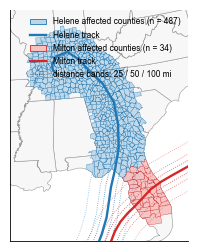

In [25]:
def _load_track(hkey):
    tg = gpd.read_file(TRACK_SHP[hkey]).to_crs(epsg=5070)
    g0 = tg.geometry.iloc[0]
    return LineString(tg.geometry.tolist()) if g0.geom_type == 'Point' else unary_union(tg.geometry.tolist())

def panel_a_map(ax):
    counties = gpd.read_file(COUNTY_SHP).to_crs(epsg=5070)
    counties['GEOID'] = counties['GEOID'].astype(str).str.zfill(5)

    affected, tracks = {}, {}
    for hkey in HURRICANES:
        with open(COUNTIES_100[hkey]) as f:
            geoids = {ln.strip().zfill(5) for ln in f if ln.strip()}
        affected[hkey] = counties[counties['GEOID'].isin(geoids)].copy()
        tracks[hkey] = _load_track(hkey)

    # extent from affected counties
    all_aff = pd.concat([affected[h] for h in HURRICANES])
    minx, miny, maxx, maxy = all_aff.total_bounds
    pad = 0.08*max(maxx-minx, maxy-miny)

    # state backdrop
    counties.dissolve(by='STATEFP').plot(ax=ax, facecolor='#f7f7f7', edgecolor='#999', linewidth=0.4)

    # distance-band rings (dotted, alpha fades outward); outer ring = affected-region cutoff
    for hkey, hm in HURRICANES.items():
        for j, r in enumerate(DIST_BANDS_MI):
            ring = gpd.GeoSeries([tracks[hkey].buffer(r*MI)], crs='EPSG:5070')
            ring.boundary.plot(ax=ax, color=hm['color'], linewidth=0.6,
                               linestyle=':', alpha=0.85 - 0.18*j)

    # affected counties + tracks
    for hkey, hm in HURRICANES.items():
        affected[hkey].plot(ax=ax, facecolor=hm['fill'], edgecolor=hm['color'], linewidth=0.25, alpha=0.9)
    for hkey, hm in HURRICANES.items():
        gpd.GeoSeries([tracks[hkey]], crs='EPSG:5070').plot(ax=ax, color=hm['color'], linewidth=1.7)

    ax.set_xlim(minx-pad, maxx+pad); ax.set_ylim(miny-pad, maxy+pad)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

    handles = []
    for hkey, hm in HURRICANES.items():
        handles += [mpatches.Patch(facecolor=hm['fill'], edgecolor=hm['color'], linewidth=0.6,
                        label=f"{hm['label']} affected counties (n = {len(affected[hkey])})"),
                    Line2D([0],[0], color=hm['color'], linewidth=1.7, label=f"{hm['label']} track")]
    handles.append(Line2D([0],[0], color='#444', linewidth=0.6, linestyle=':',
                          label='distance bands: ' + ' / '.join(f'{r}' for r in DIST_BANDS_MI) + ' mi'))
    ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=6)
    # ax.text(-0.01, 1.02, 'a', transform=ax.transAxes, fontsize=11, fontweight='bold', va='bottom', ha='left')

fig_a, ax_a = plt.subplots(figsize=(3., 3.))
panel_a_map(ax_a)
save_panel(fig_a, 'figure1a_map')
plt.show()

## Panel (b) - conceptual schematic
Saves `figure1b_schematic.{pdf,png}`. Decorative; no data dependency.

  saved -> figure1b_schematic (.pdf/.png)


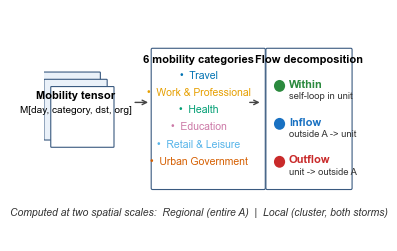

In [24]:
def panel_b_schematic(ax):
    ax.set_xlim(0,10); ax.set_ylim(0,7); ax.set_aspect('auto'); ax.axis('off')

    # Block 1: mobility tensor (stacked rounded rectangles)
    tx, ty = 0.8, 4.2
    for i, dz in enumerate([0.0, 0.22, 0.44]):
        ax.add_patch(FancyBboxPatch((tx-1.0+dz, ty-0.9-dz), 2.0, 1.8, boxstyle='round,pad=0.02',
                     facecolor='#eaf1f9' if i < 2 else 'white', edgecolor='#3a5a80', linewidth=0.8, zorder=i))
    ax.text(tx+0.22, ty+0.18, 'Mobility tensor', ha='center', va='center', fontsize=8, fontweight='bold', zorder=10)
    ax.text(tx+0.22, ty-0.25, 'M[day, category, dst, org]', ha='center', va='center', fontsize=7.2, zorder=10)
    ax.annotate('', xy=(3.45,4.2), xytext=(2.85,4.2), arrowprops=dict(arrowstyle='->', color='#444', lw=1.0))

    # Block 2: 6 categories
    cx = 5.0
    ax.add_patch(FancyBboxPatch((cx-1.5,1.6), 3.6, 4.2, boxstyle='round,pad=0.04',
                 facecolor='white', edgecolor='#3a5a80', linewidth=0.8))
    ax.text(cx, 5.5, '6 mobility categories', ha='center', va='center', fontsize=8, fontweight='bold')
    for i, cat in enumerate(CATEGORIES):
        ax.text(cx, 5.0-i*0.52, '•  '+cat, ha='center', va='center', fontsize=7.5, color=CATEGORY_COLORS[cat])
    ax.annotate('', xy=(7.05,4.2), xytext=(6.55,4.2), arrowprops=dict(arrowstyle='->', color='#444', lw=1.0))

    # Block 3: flow decomposition
    fx = 8.55
    ax.add_patch(FancyBboxPatch((fx-1.35,1.6), 2.7, 4.2, boxstyle='round,pad=0.04',
                 facecolor='white', edgecolor='#3a5a80', linewidth=0.8))
    ax.text(fx, 5.5, 'Flow decomposition', ha='center', va='center', fontsize=8, fontweight='bold')
    for i, (name, col, desc) in enumerate([('Within','#2b8a3e','self-loop in unit'),
                                           ('Inflow','#1971c2','outside A -> unit'),
                                           ('Outflow','#c92a2a','unit -> outside A')]):
        y = 4.7-i*1.15
        ax.add_patch(mpatches.Circle((fx-0.95, y), 0.18, facecolor=col, edgecolor='none'))
        ax.text(fx-0.65, y+0.04, name, ha='left', va='center', fontsize=8, fontweight='bold', color=col)
        ax.text(fx-0.65, y-0.32, desc, ha='left', va='center', fontsize=6.8, color='#333')

    ax.text(5.0, 0.85, 'Computed at two spatial scales:  Regional (entire A)  |  Local (cluster, both storms)',
            ha='center', va='center', fontsize=7.5, style='italic', color='#333')
    # ax.text(-0.01, 1.02, 'b', transform=ax.transAxes, fontsize=11, fontweight='bold', va='bottom', ha='left')

fig_b, ax_b = plt.subplots(figsize=(4.0, 3))
panel_b_schematic(ax_b)
save_panel(fig_b, 'figure1b_schematic')
plt.show()

## Panel (c) - worked-example recovery series
For each (hurricane, flow in {within, inflow}, category): observed vs SARIMAX baseline (+95% CI), the trough
(reconstructed from the cached series, since the 100-mi metrics CSV stores `largest_drop`/`recovery_days` but not
dates), and the Theil-Sen recovery to landfall+`recovery_days`. Saves
`figure1c_worked_{hurricane}_{flow}_{category}.{pdf,png}` (24 panels) + renders `EXAMPLE` inline.

  saved -> figure1c_worked_helene_within_Travel (.pdf/.png)
  saved -> figure1c_worked_helene_within_Work_and_Professional (.pdf/.png)
  saved -> figure1c_worked_helene_within_Health (.pdf/.png)
  saved -> figure1c_worked_helene_within_Education (.pdf/.png)
  saved -> figure1c_worked_helene_within_Retail_and_Leisure (.pdf/.png)
  saved -> figure1c_worked_helene_within_Urban_Government (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Travel (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Work_and_Professional (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Health (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Education (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Retail_and_Leisure (.pdf/.png)
  saved -> figure1c_worked_helene_inflow_Urban_Government (.pdf/.png)
  saved -> figure1c_worked_milton_within_Travel (.pdf/.png)
  saved -> figure1c_worked_milton_within_Work_and_Professional (.pdf/.png)
  saved -> figure1c_worked_milton_within_Health (.pdf/.png)
  sav

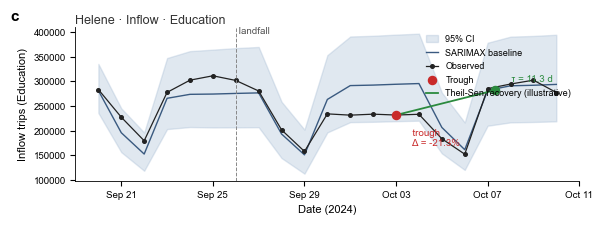

done: figure1a, figure1b, and 24 figure1c_worked_* panels


In [6]:
def panel_c_worked_example(ax, hkey, flow, cat, letter=None):
    bl = pd.read_csv(REGIONAL/hkey/f'baseline_{flow}_{category_to_filename(cat)}.csv',
                     index_col=0, parse_dates=True)
    row = METRICS[(METRICS.hurricane==hkey)&(METRICS.flow_type==flow)&(METRICS.category==cat)].iloc[0]
    landing = HURRICANES[hkey]['landing']
    recovery_days = row['recovery_days']

    # reconstruct trough = min relative deviation in [landing, landing+10] (covers Helene's lagged inflow trough)
    rd = (bl['y_true']-bl['y_pred'])/bl['y_pred']*100.0
    drop_win = rd.loc[landing:landing+pd.Timedelta(days=10)]
    trough_date = drop_win.idxmin(); trough_drop = drop_win.min()
    trough_val  = bl.loc[trough_date, 'y_true']

    win_end_days = max(14, (np.ceil(recovery_days)+1) if pd.notna(recovery_days) else 14)
    bl_w = bl.loc[landing-pd.Timedelta(days=10):landing+pd.Timedelta(days=win_end_days)]

    ax.fill_between(bl_w.index, bl_w['ci_lower'], bl_w['ci_upper'], color='#9bb4cf', alpha=0.30, label='95% CI')
    ax.plot(bl_w.index, bl_w['y_pred'], color='#3a5a80', linewidth=1.0, label='SARIMAX baseline')
    ax.plot(bl_w.index, bl_w['y_true'], color='#222', linewidth=0.9, marker='o', markersize=2.6, label='Observed')

    ax.axvline(landing, color='#888', linestyle='--', linewidth=0.7)
    ax.text(landing, ax.get_ylim()[1], ' landfall', ha='left', va='top', fontsize=7, color='#555')

    ax.scatter([trough_date], [trough_val], s=34, color='#c92a2a', zorder=5, label='Trough')
    ax.annotate(f'  trough\n  Δ = {trough_drop:.1f}%', xy=(trough_date, trough_val),
                xytext=(8,-22), textcoords='offset points', fontsize=7, color='#c92a2a')

    if pd.notna(recovery_days) and recovery_days > 0:
        recovery_date = landing + pd.Timedelta(days=float(recovery_days))
        rec_val = bl.loc[bl.index.asof(recovery_date), 'y_pred']
        ax.plot([trough_date, recovery_date], [trough_val, rec_val], color='#2b8a3e', linewidth=1.3,
                label='Theil-Sen recovery (illustrative)')
        ax.scatter([recovery_date], [rec_val], s=34, color='#2b8a3e', zorder=5)
        ax.annotate(f'  τ = {recovery_days:.1f} d', xy=(recovery_date, rec_val),
                    xytext=(8,6), textcoords='offset points', fontsize=7, color='#2b8a3e')

    ax.set_xlabel('Date (2024)'); ax.set_ylabel(f'{flow.capitalize()} trips ({cat})')
    ax.legend(loc='upper right', frameon=False, fontsize=6.5, ncol=1, handlelength=1.4)
    ax.xaxis.set_major_locator(DayLocator(interval=4)); ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_title(f"{HURRICANES[hkey]['label']} · {flow.capitalize()} · {cat}",
                 loc='left', fontsize=9, color='#333', pad=2)
    if letter:
        ax.text(-0.13, 1.02, letter, transform=ax.transAxes, fontsize=11, fontweight='bold', va='bottom', ha='left')

# Generate ALL: 6 categories x {within, inflow} x both storms = 24 files (user picks + assembles)
for hkey in HURRICANES:
    for flow in ['within','inflow']:
        for cat in CATEGORIES:
            fig, ax = plt.subplots(figsize=(6.5, 2.0))
            panel_c_worked_example(ax, hkey, flow, cat)
            save_panel(fig, f'figure1c_worked_{hkey}_{flow}_{category_to_filename(cat)}')
            plt.close(fig)

# Highlighted example, rendered inline with the 'c' panel letter
fig_c, ax_c = plt.subplots(figsize=(6.5, 2.0))
panel_c_worked_example(ax_c, EXAMPLE['hurricane'], EXAMPLE['flow_type'], EXAMPLE['category'], letter='c')
plt.show()
print('done: figure1a, figure1b, and 24 figure1c_worked_* panels')

### Caption draft (for the assembled Fig. 1)

**Fig. 1 | Study setup and analysis framework.**
**(a)** Counties affected by Hurricane Helene (blue, *n* = 487, landfall 2024-09-26) and Hurricane Milton
(red, *n* = 34, landfall 2024-10-09), defined as counties within **100 mi** of the official storm track.
Dotted rings show the 25 / 50 / 100-mi distance bands; the 100-mi ring is the affected-region cutoff. Solid
lines are the storm tracks.
**(b)** Analytical pipeline. The 4-D mobility tensor *M*[day, category, dst, org] is filtered to six
urban-functional categories (Utilities excluded) and decomposed into within, inflow, and outflow at two spatial
scales - regional (entire affected area *A*) and local (cluster, both storms).
**(c)** Worked example. Observed trips (black) deviate from the SARIMAX counterfactual (navy, 95% CI shaded)
after landfall. The trough (red) marks peak disruption (Δ); recovery time τ is measured from landfall to the
Theil-Sen recovery line's zero-crossing (green).

*Set `EXAMPLE` to the panel you assemble, and copy its Δ / τ into the caption.*